# Pareto $k$ analysis

## 1. Background: what is $k$?

The consensus model draws each node's raw stake $w_i$ from a **Pareto**
distribution and normalises it to a relative stake $\alpha_i = w_i / \sum_j w_j$
(see *Consensus Model* §2). The Pareto has two parameters:

* shape $k$
* scale $x_m$

But the scale cancels under normalisation, so $k$ is the only real tuneable
parameter.

**Why the scale cancels.** The scale $x_m$ enters the Pareto purely as a
multiplicative factor: if $w_i \sim \mathrm{Pareto}(k, x_m)$ then
$w_i = x_m \cdot u_i$ where $u_i \sim \mathrm{Pareto}(k, 1)$ is the same draw with
unit scale. Substituting into the normalisation, the common factor $x_m$ pulls
out of both the numerator and every term of the denominator and divides away:

$$
\alpha_i = \frac{w_i}{\sum_j w_j}
         = \frac{x_m\,u_i}{\sum_j x_m\,u_j}
         = \frac{x_m\,u_i}{x_m \sum_j u_j}
         = \frac{u_i}{\sum_j u_j}.
$$

The relative stakes $\alpha_i$ depend only on the unit-scale draws $u_i$, i.e. on
$k$ alone — so we fix $x_m = 1$ as a convention and tune only $k$.

What $k$ controls is **stake inequality**, i.e. how unevenly stake is split
across nodes:

* small $k$ $\Rightarrow$ a heavy tail — a few large nodes hold most of the stake;
* large $k$ $\Rightarrow$ the distribution concentrates onto its lower bound, so
   every node tends toward an equal share $\alpha_i \approx 1/N$.

So choosing $k$ is choosing how unequal the simulated validator set is — the
single number that fixes the shape of the entire stake distribution.

**Why do we need an "optimum" $k$?** The earlier baseline $k = 2$ was a
placeholder. Because $k$ sets the whole shape of the stake distribution, an
arbitrary value makes the whole simulation arbitrary. Calibrating $k$ to a real
chain therefore adds realism to the simulator: the stake distribution it runs on
is no longer a guess but a match to an actual deployed proof-of-stake network
(Cardano).


## Setup

In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

# Locate the repo root (works whether the notebook runs from notebooks/ or root)
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "src").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "src"))

import plotstyle                       # house figure style (auto-applied on import)
from consensus import gini, sample_relative_stakes, shape_from_gini

N = 1000          # nodes per sampled stake vector
SEED = 0

# Figures are saved to results/figures/ (like the rest of the repo) AND shown inline.
FIG_DIR = REPO_ROOT / "results" / "figures" / "stage_2_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_show(fig, name):
    # Save a figure to results/figures/ then display it inline.
    fig.savefig(FIG_DIR / name, dpi=150)
    plt.show()

print(f"repo root: {REPO_ROOT}")
print(f"figures   -> {FIG_DIR}")
print(f"LaTeX rendering: {plotstyle.USING_TEX}")

repo root: c:\Users\lucas\Desktop\Lucas UCL FinTech\COMP0176 MSc FinTech Summer Project\traffic_analysis
figures   -> c:\Users\lucas\Desktop\Lucas UCL FinTech\COMP0176 MSc FinTech Summer Project\traffic_analysis\results\figures\stage_2_figures
LaTeX rendering: True


## 2. The shape parameter $k$ and the Gini coefficient

We need a bridge from "a real chain's inequality" to "a value of $k$". That bridge
is the **Gini coefficient** $G \in (0, 1)$ — one interpretable scalar ($0$ =
perfectly equal, $\to 1$ = one node owns everything). For the classical Pareto(I)
distribution the Gini has a closed form (Arnold, *Pareto Distributions*, 2nd ed.
2015, p. 150):

$$G = \frac{1}{2k - 1}, \qquad\Longleftrightarrow\qquad k = \frac{1 + G}{2G}.$$

Inequality depends on $k$ through this. The inverse $k = (1+G)/2G$ is
`shape_from_gini` in `src/consensus`.

The same page also gives the **Lorenz curve** $L(u)$: rank nodes poorest to
richest, then $L(u)$ is the cumulative share of total stake held by the bottom
fraction $u$. Perfect equality is the diagonal $L(u) = u$; the curve's sag below
it is the inequality (the Gini is twice the area between them). For the Pareto
(Arnold, 2015, p. 150):

$$L(u) = 1 - (1-u)^{(k-1)/k},$$

the share of stake held by the *poorest* fraction $u$ of nodes. The **top-share**
law — the share held by the *richest* fraction $u$ — is its complement. The
richest $u$ holds everything except what the poorest $1-u$ holds, i.e.
$S(u) = 1 - L(1-u)$. Substituting $1-u$ into the Lorenz curve and simplifying:

$$
\begin{aligned}
S(u) &= 1 - L(1-u) \\
     &= 1 - \Bigl[\,1 - \bigl(1 - (1-u)\bigr)^{(k-1)/k}\,\Bigr] \\
     &= 1 - \Bigl[\,1 - u^{(k-1)/k}\,\Bigr] \\
     &= u^{(k-1)/k}.
\end{aligned}
$$

This second form lets us calibrate from a "top-$x\%$ hold half" statistic, which
is the route we ultimately use (§4).


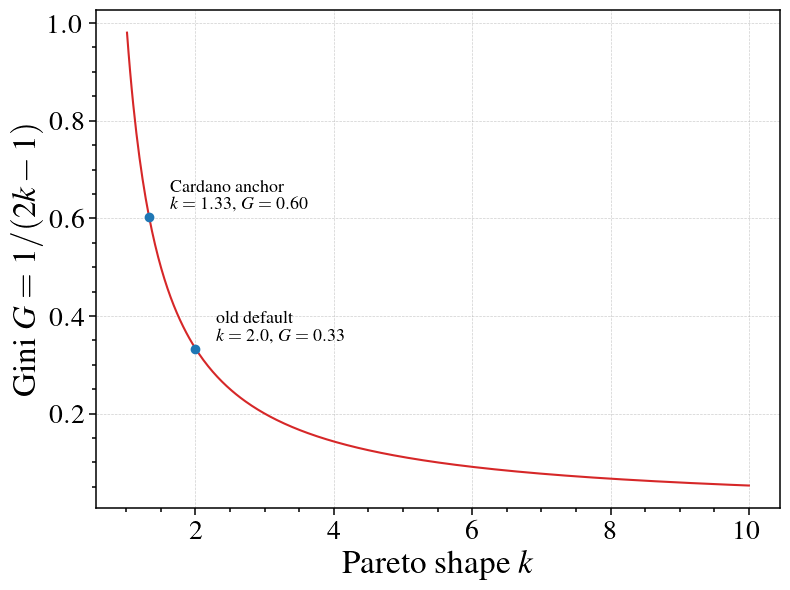

shape_from_gini(0.60) = 1.333


In [2]:
k = np.linspace(1.01, 10, 400)
G = 1.0 / (2.0 * k - 1.0)

fig, ax = plt.subplots()
ax.plot(k, G, color="C3")
for kv, lab in [(1.33, "Cardano anchor"), (2.0, "old default")]:
    gv = 1.0 / (2.0 * kv - 1.0)
    ax.plot(kv, gv, "o", color="C0")
    ax.annotate(f"{lab}\n$k={kv}$, $G={gv:.2f}$", (kv, gv),
                textcoords="offset points", xytext=(15, 5), fontsize=13)
ax.set_xlabel(r"Pareto shape $k$")
ax.set_ylabel(r"Gini $G = 1/(2k-1)$")
plt.show()   # illustrative only -- not saved to results/figures/
print("shape_from_gini(0.60) =", round(shape_from_gini(0.60), 3))

## 3. Validation: the stake-Gini sweep

A closed form is only useful if a *finite* sample of $N = 1000$ nodes actually
achieves that Gini. We sweep $k$, sample the relative stakes (mean $\pm$ 1 std
over 50 seeds), and compare the **sampled** Gini against $1/(2k-1)$.


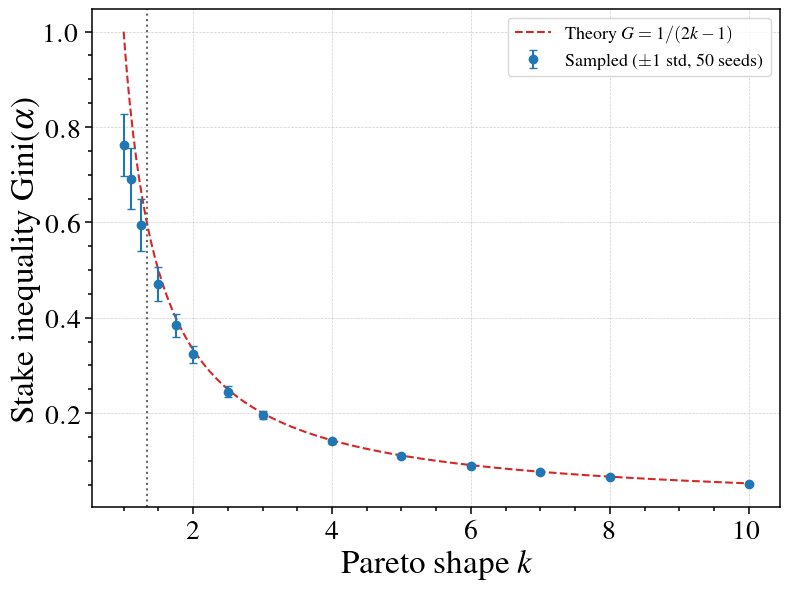

k= 1.00  G_theory=1.000  G_sampled=0.762  rel= 23.8%
k= 1.10  G_theory=0.833  G_sampled=0.692  rel= 17.0%
k= 1.25  G_theory=0.667  G_sampled=0.595  rel= 10.7%
k= 1.50  G_theory=0.500  G_sampled=0.470  rel=  5.9%
k= 1.75  G_theory=0.400  G_sampled=0.384  rel=  4.0%
k= 2.00  G_theory=0.333  G_sampled=0.323  rel=  3.0%
k= 2.50  G_theory=0.250  G_sampled=0.245  rel=  2.2%
k= 3.00  G_theory=0.200  G_sampled=0.196  rel=  1.8%
k= 4.00  G_theory=0.143  G_sampled=0.141  rel=  1.4%
k= 5.00  G_theory=0.111  G_sampled=0.110  rel=  1.3%
k= 6.00  G_theory=0.091  G_sampled=0.090  rel=  1.2%
k= 7.00  G_theory=0.077  G_sampled=0.076  rel=  1.1%
k= 8.00  G_theory=0.067  G_sampled=0.066  rel=  1.1%
k=10.00  G_theory=0.053  G_sampled=0.052  rel=  1.0%


In [3]:
SHAPES = np.array([1.0, 1.1, 1.25, 1.5, 1.75, 2.0, 2.5, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 10.0])
N_SEEDS = 50

means, stds = [], []
for kv in SHAPES:
    g = [gini(sample_relative_stakes(N, shape=kv, rng=s)) for s in range(N_SEEDS)]
    means.append(np.mean(g)); stds.append(np.std(g))
means, stds = np.array(means), np.array(stds)

fig, ax = plt.subplots()
kk = np.linspace(SHAPES.min(), SHAPES.max(), 400)
ax.plot(kk, 1.0 / (2.0 * kk - 1.0), "--", color="C3", label=r"Theory $G=1/(2k-1)$")
ax.errorbar(SHAPES, means, yerr=stds, fmt="o", color="C0", capsize=3,
            label=fr"Sampled ($\pm1$ std, {N_SEEDS} seeds)")
ax.axvline(1.33, color="0.4", ls=":", lw=1.5)
ax.set_xlabel(r"Pareto shape $k$"); ax.set_ylabel(r"Stake inequality Gini($\alpha$)")
ax.legend(fontsize=13)
save_show(fig, "stake_gini_sweep.png")

# relative error vs theory
for kv, m in zip(SHAPES, means):
    gc = 1.0 / (2.0 * kv - 1.0)
    print(f"k={kv:5.2f}  G_theory={gc:.3f}  G_sampled={m:.3f}  rel={abs(m-gc)/gc:6.1%}")

For $k \ge 1.5$ the sampler tracks $1/(2k-1)$ to within a few percent. It breaks
only at the $k = 1$ boundary: there the Pareto mean diverges, the normalising sum
$\sum_j w_j$ is dominated by its single largest term, the draw stops
self-averaging, and the sampled Gini saturates near $0.76$ (not $1$) and fans out
across seeds. The usable inequality range for finite samples is therefore roughly
$G \in (0,\ \sim 0.8)$ — our eventual anchor $k = 1.33$ sits just inside it.


## 4. Calibrating to Cardano

The published Cardano Gini $\approx 0.82$ measures **ADA across token holders /
addresses** — *not* what we want. (That figure, with the top $0.1\%$ holding
$\approx 70\%$ of supply, is a *holder-level wealth* Gini —
[OxJournal, *The Decentralisation Dilemma*](https://www.oxjournal.org/the-decentralisation-dilemma/).)
Our model's nodes are stake **pools** (a pool wins blocks in proportion to its
*active stake*), so the calibration target is the **active-stake distribution
across pools** — a different population entirely. We therefore ignore the
published holder figure and measure the pool-stake distribution ourselves (§4b).

There are two ways to turn Cardano pool data into $k$:

* **Top-share route** — from a published "top $x\%$ hold half" figure (§4a).
* **Direct Gini route** — measure the Gini of the pool active-stake vector and
  invert $k = (1+G)/2G$ (§4b).


### 4a. Messari report + worked example

Cardano's top $\approx 6\%$ of pools hold $50\%$ of stake
([Messari, *State of Cardano Q4 2023*](https://messari.io/report/state-of-cardano-q4-2023)).
Solve $S(0.06) = 0.5$ for $k$. Take logs to bring the exponent down:

$$0.06^{(k-1)/k} = 0.5
\;\Longrightarrow\;
\frac{k-1}{k} = \frac{\ln 0.5}{\ln 0.06} = \frac{-0.6931}{-2.8134} = 0.2464.$$

Using $\dfrac{k-1}{k} = 1 - \dfrac{1}{k}$:

$$1 - \frac{1}{k} = 0.2464
\;\Longrightarrow\;
k = \frac{1}{1 - \ln 0.5/\ln 0.06} = 1.327.$$

Convert to the model Gini: $G = 1/(2 \cdot 1.327 - 1) = 0.605 \approx 0.60$.

The cell below evaluates exactly this (and re-uses the same `k_from_top_share`
for the live top-share later).


In [4]:
from math import log

def k_from_top_share(u, share=0.5):
    # Solve  u**((k-1)/k) = share  for the Pareto shape k.
    return 1.0 / (1.0 - log(share) / log(u))

# Top-share route, using the published "top 6% -> 50%" figure.
u_top = 0.06
k_top = k_from_top_share(u_top)
print(f"top {u_top:.0%} -> 50%  =>  k = {k_top:.3f}  =>  model G = {1/(2*k_top-1):.3f}")

top 6% -> 50%  =>  k = 1.327  =>  model G = 0.605


### 4b. Koios live pull

To make the snapshot reproducible (and not rely on a single published number), we
pull the pool active-stake vector **live** from the Koios API (`/tip`,
`/pool_list`), quote the epoch, and apply both routes. A cached snapshot is used
if the API is offline.


In [5]:
import json, urllib.request
from datetime import datetime, timezone

KOIOS = "https://api.koios.rest/api/v1"
PAGE = 1000

# Cached snapshot (epoch 638, 2026-06-23) used if the live pull is unavailable.
CACHED = dict(epoch=638, date="2026-06-23", n_pools=2709, total_ada=21_614_522_361,
              gini=0.841, top_frac=0.059, nakamoto_pools=160, nakamoto_groups=17)

def _get(path):
    req = urllib.request.Request(KOIOS + path, headers={"accept": "application/json"})
    with urllib.request.urlopen(req, timeout=60) as r:
        return json.loads(r.read())

def pull_live():
    tip = _get("/tip")[0]
    epoch = tip["epoch_no"]
    when = datetime.fromtimestamp(tip["block_time"], timezone.utc)
    stakes, groups, offset = [], [], 0
    while True:
        rows = _get(f"/pool_list?select=pool_id_bech32,pool_group,active_stake"
                    f"&offset={offset}&limit={PAGE}")
        if not rows:
            break
        for row in rows:
            s = row.get("active_stake")
            if s and int(s) > 0:
                stakes.append(int(s))
                groups.append(row.get("pool_group") or row["pool_id_bech32"])
        if len(rows) < PAGE:
            break
        offset += PAGE
    stakes = np.array(stakes, float)
    desc = np.sort(stakes)[::-1]
    cum = np.cumsum(desc) / desc.sum()
    nc_pools = int(np.searchsorted(cum, 0.5) + 1)
    by_op = {}
    for g, s in zip(groups, stakes):
        by_op[g] = by_op.get(g, 0.0) + s
    op_desc = np.sort(np.fromiter(by_op.values(), float))[::-1]
    nc_groups = int(np.searchsorted(np.cumsum(op_desc) / op_desc.sum(), 0.5) + 1)
    return dict(epoch=epoch, date=f"{when:%Y-%m-%d}", n_pools=stakes.size,
                total_ada=stakes.sum()/1e6, gini=gini(stakes),
                top_frac=nc_pools/stakes.size, nakamoto_pools=nc_pools,
                nakamoto_groups=nc_groups)

try:
    snap = pull_live()
    print("LIVE Koios pull succeeded")
except Exception as e:           # offline / API down -> cached snapshot
    snap = CACHED
    print(f"(live pull unavailable: {e}\n -> using cached snapshot)")

print(f"\nCardano snapshot: epoch {snap['epoch']} ({snap['date']})")
print(f"  pools with stake : {snap['n_pools']}")
print(f"  total active ADA : {snap['total_ada']:,.0f}")
print(f"  pool-stake Gini  : {snap['gini']:.3f}")
print(f"  top-share        : top {snap['top_frac']:.1%} of pools hold 50%")
print(f"  Nakamoto coeff   : {snap['nakamoto_pools']} pools "
      f"({snap['nakamoto_groups']} operator groups)")

k_gini = shape_from_gini(snap['gini'])
k_share = k_from_top_share(snap['top_frac'])
print(f"\n  from measured Gini  G={snap['gini']:.3f}  ->  k={k_gini:.3f}  "
      f"(model G={1/(2*k_gini-1):.3f})")
print(f"  from top {snap['top_frac']:.1%} -> 50%      ->  k={k_share:.3f}  "
      f"(model G={1/(2*k_share-1):.3f})")

(live pull unavailable: <urlopen error [Errno 11002] getaddrinfo failed>
 -> using cached snapshot)

Cardano snapshot: epoch 638 (2026-06-23)
  pools with stake : 2709
  total active ADA : 21,614,522,361
  pool-stake Gini  : 0.841
  top-share        : top 5.9% of pools hold 50%
  Nakamoto coeff   : 160 pools (17 operator groups)

  from measured Gini  G=0.841  ->  k=1.095  (model G=0.841)
  from top 5.9% -> 50%      ->  k=1.324  (model G=0.607)


## 5. Why the two routes disagree — and the choice

The same data gives **$G \approx 0.60$** (top-share, $k \approx 1.33$) but
**$G \approx 0.84$** (direct Gini, $k \approx 1.10$). They differ because
Cardano's pool distribution is **not a clean Pareto**: a single shape $k$ cannot
simultaneously reproduce the concentrated *top* (a few large pools) **and** the
long tail of $\sim 2{,}700$ tiny pools. Matching the top concentration
understates the overall Gini; matching the overall Gini lands at $k \approx 1.10$,
which is in the sampler's breakdown zone (§3) and is essentially the inequality
*limit* already.

**We focus on the top-concentration route: $k = 1.33$, $G = 0.60$.** Because:

* it is the value our sampler can *faithfully reproduce* at finite $N$ (§3);
* the "top 6% hold half" fact is what drives the anonymity story — a few
  high-stake pools broadcast often and are easy to single out;
* it is corroborated by **two independent sources** —
  [Messari *State of Cardano Q4 2023*](https://messari.io/report/state-of-cardano-q4-2023)
  (top 6.0% $\to$ 50%) and the live Koios pull above (top 5.9% $\to$ 50%).

The $0.60$-vs-$0.84$ gap is itself a finding worth carrying forward: Cardano's
stake is too non-Pareto for one number to capture both its top concentration and
its overall inequality.


## 6. The three regimes

Inspect the stake histograms at the **equality limit**, the **Cardano anchor**,
and the **inequality limit** ($N = 1000$). The last column, $\max_i \alpha_i$, is
the largest single node's relative stake — the biggest whale's share (recall
$\sum_i \alpha_i = 1$, so the uniform baseline is $1/N = 0.001$).


In [6]:
CARDANO_GINI = 0.60
REGIMES = [
    (r"Equality limit  ($k=10$)", 10.0, 1/(2*10-1), "C2"),
    (fr"Cardano pools  ($G={CARDANO_GINI:.2f}$)", shape_from_gini(CARDANO_GINI), CARDANO_GINI, "C0"),
    (r"Inequality limit  ($k=1$)", 1.0, 1.0, "C3"),
]

samples = []
for j, (label, kv, g_closed, colour) in enumerate(REGIMES):
    alpha = sample_relative_stakes(N, shape=kv, rng=SEED + 10 * j)
    samples.append(dict(label=label, k=kv, g_closed=g_closed, colour=colour,
                        g_sampled=gini(alpha), alpha=alpha, max=float(alpha.max())))

print(f"{'regime':>26} {'k':>7} {'G_theory':>9} {'G_sampled':>10} {'max a':>9}")
for r in samples:
    name = r['label'].replace('$', '').replace('\\', '')
    print(f"{name:>26} {r['k']:7.3f} {r['g_closed']:9.3f} {r['g_sampled']:10.3f} {r['max']:9.4f}")

                    regime       k  G_theory  G_sampled     max a
    Equality limit  (k=10)  10.000     0.053      0.052    0.0019
   Cardano pools  (G=0.60)   1.333     0.600      0.610    0.0765
   Inequality limit  (k=1)   1.000     1.000      0.760    0.1460


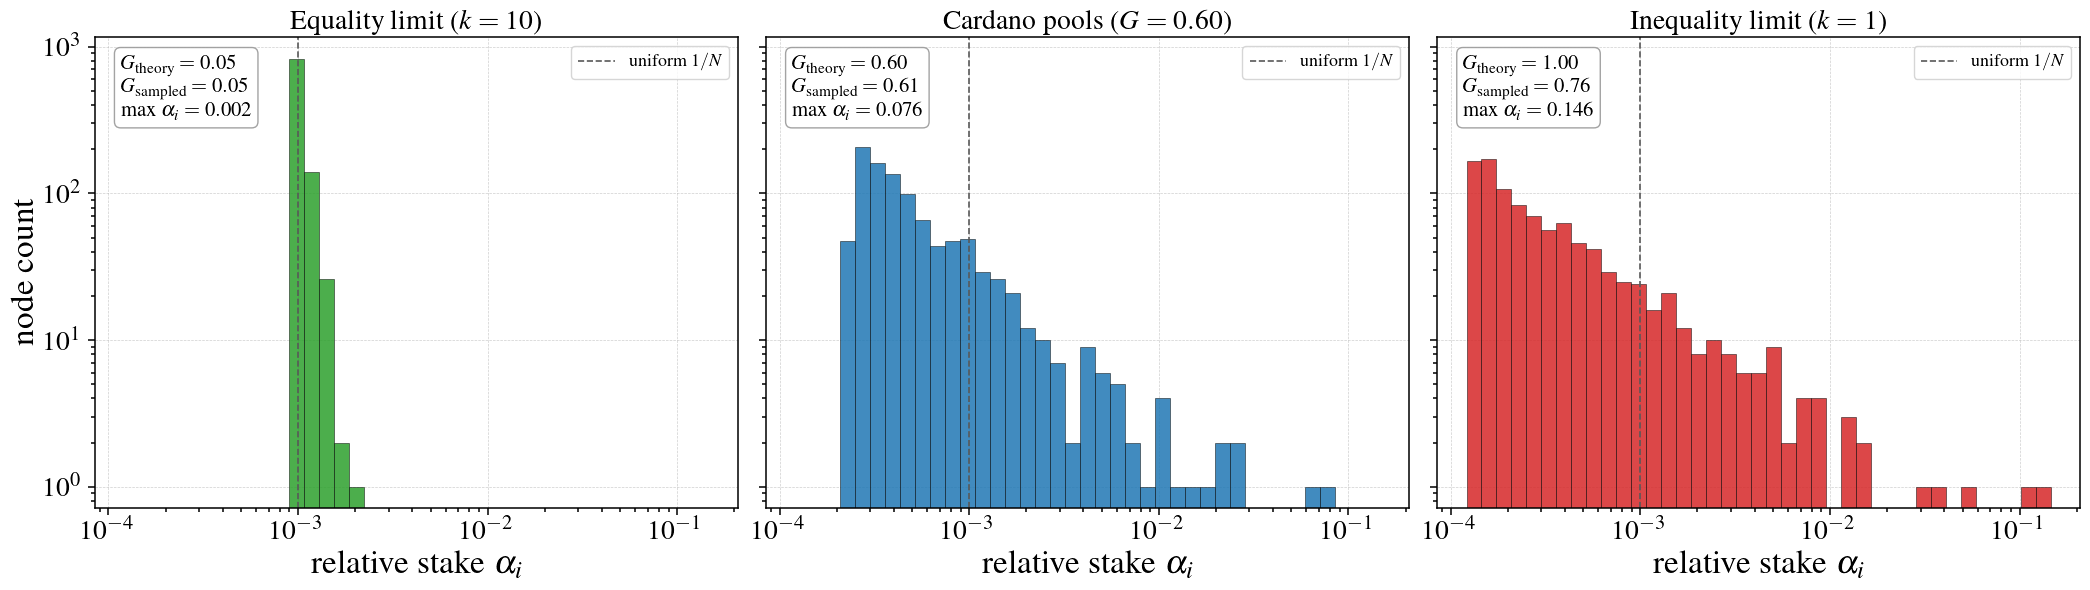

In [7]:
amin = min(r['alpha'].min() for r in samples)
amax = max(r['max'] for r in samples)
bins = np.logspace(np.log10(amin), np.log10(amax), 40)

fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharex=True, sharey=True)
for ax, r in zip(axes, samples):
    ax.hist(r['alpha'], bins=bins, color=r['colour'], alpha=0.85,
            edgecolor='black', linewidth=0.4)
    ax.axvline(1.0 / N, ls='--', color='0.35', lw=1.2, label=r'uniform $1/N$')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel(r'relative stake $\alpha_i$')
    ax.set_title(r['label'], fontsize=20)
    ax.text(0.04, 0.96,
            fr"$G_\mathrm{{theory}}={r['g_closed']:.2f}$" + "\n"
            fr"$G_\mathrm{{sampled}}={r['g_sampled']:.2f}$" + "\n"
            fr"$\max\,\alpha_i={r['max']:.3f}$",
            transform=ax.transAxes, fontsize=15, va='top',
            bbox=dict(boxstyle='round', fc='white', ec='0.6', alpha=0.9))
    ax.legend(fontsize=13, loc='upper right')
axes[0].set_ylabel(r'node count')
save_show(fig, "stake_distribution_histograms.png")

* **Equality limit ($k=10$).** Stake is nearly flat — the largest node holds only
  $\approx 2/N$. No large node to single out.
* **Cardano anchor ($k=1.33$).** A clear heavy tail: the largest pool holds
  $\approx 7.7\%$ of all stake — the calibrated operating point.
* **Inequality limit ($k=1$).** Singular: the sampled Gini reaches only
  $\approx 0.76$ (not 1) and a single node holds $\approx 15\%$ of stake, set by
  whichever draw happened to be largest.


## 7. The experimental sweep

Section 6 fixed the three *conceptual* regimes (equality limit, Cardano anchor,
inequality limit). For the actual experiments we need a small set of **operating
points** to push through the anonymity pipeline. We choose them by **Gini** — the
interpretable axis — and convert with $k = (1+G)/2G$, keeping every point inside the
**faithful-sampling region** ($k \gtrsim 1.2$, §3).

Cardano ($G = 0.60$) is already quite unequal, so there is **wide room towards
equality** (raise $k$) but only **a sliver towards more inequality** (lower $k$)
before finite-$N$ sampling breaks down. We therefore take the **bare-minimum three** —
the Cardano anchor plus one step **lower** and one step **higher** in $k$:

| direction | $k$ | $G = 1/(2k-1)$ |
|---|---|---|
| less equal (faithful edge) | 1.20 | 0.71 |
| **Cardano anchor** | 1.33 | 0.60 |
| more equal | 1.75 | 0.40 |

In [8]:
# Experimental operating sweep: the bare-minimum three points -- the Cardano anchor
# plus one a bit lower and one a bit higher in k. Chosen by Gini, all inside the
# faithful-sampling region (k >= ~1.2, see section 3).
SWEEP = [
    (r"Less equal  ($G=0.71$)", 1.20, "C3"),
    (fr"Cardano anchor  ($G={CARDANO_GINI:.2f}$)", shape_from_gini(CARDANO_GINI), "C0"),
    (r"More equal  ($G=0.40$)", 1.75, "C2"),
]

sweep = []
for j, (label, kv, colour) in enumerate(SWEEP):
    alpha = sample_relative_stakes(N, shape=kv, rng=SEED + 10 * j)
    sweep.append(dict(label=label, k=kv, g_closed=1.0 / (2.0 * kv - 1.0), colour=colour,
                      g_sampled=gini(alpha), alpha=alpha, max=float(alpha.max())))

print(f"{'operating point':>26} {'k':>7} {'G_theory':>9} {'G_sampled':>10} {'max a':>9}")
for r in sweep:
    name = r['label'].replace('$', '').replace('\\', '')
    print(f"{name:>26} {r['k']:7.3f} {r['g_closed']:9.3f} {r['g_sampled']:10.3f} {r['max']:9.4f}")

SWEEP_SHAPES = [r['k'] for r in sweep]   # downstream experiments pull from this set
print("\nSWEEP_SHAPES =", [round(k, 3) for k in SWEEP_SHAPES])

           operating point       k  G_theory  G_sampled     max a
      Less equal  (G=0.71)   1.200     0.714      0.617    0.1224
  Cardano anchor  (G=0.60)   1.333     0.600      0.610    0.0765
      More equal  (G=0.40)   1.750     0.400      0.388    0.0254

SWEEP_SHAPES = [1.2, 1.333, 1.75]


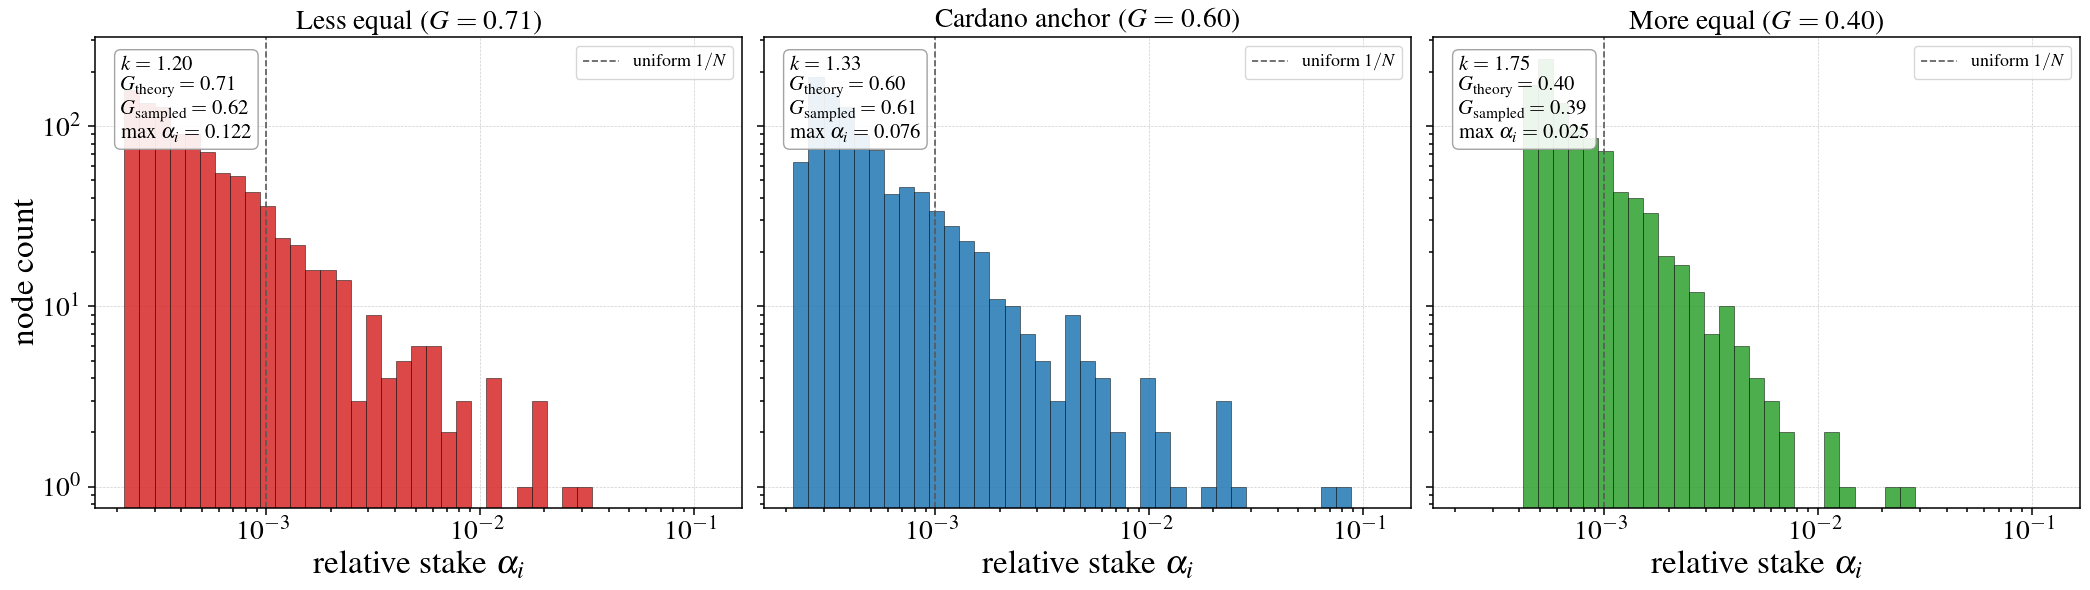

In [9]:
amin = min(r['alpha'].min() for r in sweep)
amax = max(r['max'] for r in sweep)
bins = np.logspace(np.log10(amin), np.log10(amax), 40)

fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharex=True, sharey=True)
for ax, r in zip(axes, sweep):
    ax.hist(r['alpha'], bins=bins, color=r['colour'], alpha=0.85,
            edgecolor='black', linewidth=0.4)
    ax.axvline(1.0 / N, ls='--', color='0.35', lw=1.2, label=r'uniform $1/N$')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel(r'relative stake $\alpha_i$')
    ax.set_title(r['label'], fontsize=20)
    ax.text(0.04, 0.96,
            fr"$k={r['k']:.2f}$" + "\n"
            fr"$G_\mathrm{{theory}}={r['g_closed']:.2f}$" + "\n"
            fr"$G_\mathrm{{sampled}}={r['g_sampled']:.2f}$" + "\n"
            fr"$\max\,\alpha_i={r['max']:.3f}$",
            transform=ax.transAxes, fontsize=15, va='top',
            bbox=dict(boxstyle='round', fc='white', ec='0.6', alpha=0.9))
    ax.legend(fontsize=13, loc='upper right')
axes[0].set_ylabel(r'node count')
save_show(fig, "stake_sweep_histograms.png")

* **Less equal ($k=1.20$, $G=0.71$).** The heaviest tail in the sweep — more
  concentrated than Cardano, with the largest pool's share a few points above the
  anchor's. This is about as far towards inequality as finite-$N$ sampling stays
  faithful (§3); $k=1.10$ would enter the breakdown zone, so this is the practical
  inequality edge.
* **Cardano anchor ($k=1.33$, $G=0.60$).** The calibrated operating point — heavy
  tail, largest pool $\approx 7.7\%$ of stake (matches §6).
* **More equal ($k=1.75$, $G=0.40$).** Noticeably flatter: the tail thins and the
  largest pool's share drops, so no single node dominates the message volume.

These three shapes are exported as `SWEEP_SHAPES`; the downstream anonymity
experiments run at each in turn. Wider exploration (towards the §6 equality/inequality
*limits*) can be layered on later, but these are the bare-minimum operating points —
the Cardano anchor plus one step lower and one step higher in $k$.

## References

* B. C. Arnold. *Pareto Distributions.* 2nd ed., Chapman & Hall/CRC, 2015. p. 150.
* Messari. *State of Cardano Q4 2023.* https://messari.io/report/state-of-cardano-q4-2023
* OxJournal. *The Decentralisation Dilemma.* https://www.oxjournal.org/the-decentralisation-dilemma/
* Koios API. https://api.koios.rest
